In [ ]:
pip install statsmodels pingouin #

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\anika\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
#VIF
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm 
#Mahalanobis
from scipy.stats import chi2
from numpy.linalg import inv
#Cronbach's alpha
import pingouin as pg
#OLS Analysis
import statsmodels.formula.api as smf
#Linearity Test
from statsmodels.stats.diagnostic import linear_reset
from statsmodels.stats.diagnostic import linear_rainbow
#Homoscedasticity Tests
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

In [ ]:
#SET UP 

df = pd.read_csv(r"C:\Users\anika\Desktop\Diss\Qualtrics Data\Aug10.2.csv", header=0, skiprows=[1, 2])   # make 2nd row the header (ignores the 1st row), remove the third header

#Drop unwanted columns
df = df.drop(columns = ['StartDate', 'EndDate', 'Status', 'Progress', 'UserLanguage', 
                        'Q_RecaptchaScore', 'Q_DuplicateRespondent', 'Q89', 'Q70', 
                        'SMU2_11_TEXT','score'])  
df["RecordedDate"] = pd.to_datetime(df["RecordedDate"], format="%d/%m/%Y %H:%M")                # fix date-time python reading

#EXPLORATION

df.head(10)

##to see all the rows and columns 
#pd.set_option("display.max_rows", None)
#df.dtypes

##to see all columns untruncated
#pd.set_option("display.max_columns", None)
#df

print(f"Initial sample size = {len(df)}")

Initial sample size = 936


In [4]:
df.head(5)

,Duration (in seconds),Finished,RecordedDate,ResponseId,DistributionChannel,Q1,Q3,Q5,Q6,DEP1,...,CC3,TR1,TR2,TR3,TR4,DT1,DT2,DT3,DT4,SC0
0,145,0,2026-07-02 04:51:00,R_9Qn6dlMga6ZzxbC,anonymous,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,221,1,2026-07-02 09:46:00,R_9mR4pZujjpLXbOh,anonymous,3.0,18.0,2.0,1.0,3.0,...,2.0,1.0,2.0,1.0,3.0,2.0,2.0,2.0,1.0,7
2,155,1,2026-07-02 09:57:00,R_9aqvBcW0zUumktH,anonymous,2.0,18.0,3.0,1.0,3.0,...,3.0,3.0,1.0,5.0,2.0,2.0,2.0,2.0,4.0,6
3,903,1,2026-07-03 10:40:00,R_4rprDFukwfXDERp,anonymous,2.0,24.0,6.0,3.0,4.0,...,4.0,2.0,2.0,2.0,2.0,4.0,4.0,4.0,4.0,6
4,151236,1,2026-07-06 06:16:00,R_9PrusrlyzngZaed,anonymous,2.0,24.0,1.0,3.0,3.0,...,4.0,3.0,3.0,4.0,5.0,2.0,2.0,4.0,1.0,6


In [5]:
#RENAME COLUMN NAMES for readability

rename_map = {
    # demographics
    "Q1": "Gender",
    "Q3": "Age",
    "Q5": "Year Level",
    "Q6": "Occupation/SES", 
    # video types (DF=deepfake/R=real)
    "Q125": "VID1_DF",
    "Q128": "VID2_DF",
    "Q129": "VID3_DF",
    "Q130": "VID4_DF",
    "Q131": "VID5_R",
    "Q132": "VID6_R",
    "Q133": "VID7_R",
    "Q134": "VID8_R",
    # confidence questions, after each video
    "Q77": "CONF1_DF",
    "Q75": "CONF2_DF",
    "Q76": "CONF3_DF",
    "Q79": "CONF4_DF",
    "Q83": "CONF5_R",
    "Q84": "CONF6_R",
    "Q85": "CONF7_R",
    "Q86": "CONF8_R",
}

df = df.rename(columns=rename_map)

In [6]:
#CLEAN UP

#convert str column 'age' to float column
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

#to see all the rows and columns 
pd.set_option("display.max_rows", None)
df.dtypes

Duration (in seconds)             int64
Finished                          int64
RecordedDate             datetime64[us]
ResponseId                          str
DistributionChannel                 str
Gender                          float64
Age                             float64
Year Level                      float64
Occupation/SES                  float64
DEP1                            float64
DEP2                            float64
DEP3                            float64
DEP4                            float64
DEP5                            float64
DEP6                            float64
DEP7                                str
SMU1_1                          float64
SMU2                                str
SMP1                            float64
SMP2                            float64
SMP3                            float64
SMP4                            float64
SMA1                            float64
SMA2                            float64
SMA3                            float64


In [7]:
#FILTER

#Filter out responses dated before July 7 - these are all trial responses. Official data collection stared July 7.
df = df[(df["RecordedDate"] > "2026-07-07")]

#Filter out speed responses completed faster than 7 minutes / 420 seconds (359 seconds)
df = df[(df['Duration (in seconds)'] > 419)]

#Filter out unfinished responses
df = df[(df['Finished'] == 1)] # 1 = 100% completed

#Filter out test/sample responses
df = df[(df['DistributionChannel'] == 'anonymous')]

#Filter out failed attention checks
df = df[(df['ATT1'] == 2.0)]  # 2.0 = 'unlikely'

#Filter out for universities outside metro manila (Q4) - column deleted before loading into python
#done manually before loading csv file on jupyter ntbk

#Verify count of entries after filtering
print(f"N = {len(df)}")

N = 537


In [8]:
# Manual Response Filtering of Universities Outside Metro Manila, PH. Done outside Python for confidential purposes

excluded_IDs = ['R_3Puhiyvwo4bd0Yx',
    'R_TmVMacr2ndbayzf',
    'R_2WPtif9wyCBnbQs', 
    'R_Zsoo254LTx7xqrn',
    'R_2e9GmLLYBpV9hdr',
    'R_1DJb8uO8EU38KFS',
    'R_UrLGS82o8lZ80HT',
    'R_Dvf2QKk9Krz8s6t',
    'R_2WPvFOAdNYWodvE',
    'R_3Jn01dw6ffoFmch',
    'R_1pEgRAvNL7Bjm15',
    'R_2e8ZtoeYd7IGgUs',
    'R_1DCMcm6CcotDIAe',
    'R_2QgINVqyUrU3oWL']
df = df[~df['ResponseId'].isin(excluded_IDs)]

print(f"Final N = {len(df)}")

Final N = 523


In [9]:
#Check for Missing Values - NaNs and Dirty Values

# NaN counts: empty values
print("NaN / missing per column:")
nan_counts = df.isna().sum()                                                     # count NaNs
print(nan_counts[nan_counts > 0] if (nan_counts > 0).any() else "No NaNs")       # if NaNs present, print accordingly

# Dirty values: non-numeric entries in columns that should be numeric
print("\nDirty (non-numeric) values in numeric columns:")
numeric_cols = ["Occupation/SES", "DEP1","DEP2","DEP3","DEP4","DEP5","DEP6",     # specify columns that should be numeric
                "FC1","FC2","FC3","FP1","FP2","FP3","CP1","CP2","CP3","CC1","CC2","CC3",
                "TR1","TR2","TR3","TR4","DT1","DT2","DT3","DT4",
                "SMA1","SMA2","SMA3","SMA4","SMP1","SMP2","SMP3","SMP4","SC0"]

found_dirty = False
for col in numeric_cols:
    if col in df.columns:
        coerced = pd.to_numeric(df[col], errors="coerce")
        dirty = df[coerced.isna() & df[col].notna()]            # define what 'dirty' is
        if len(dirty) > 0:                                      # if dirty values found
            found_dirty = True                                  # print number of dirty values and where
            print(f"{col}: {len(dirty)} dirty value(s) -> {df.loc[dirty.index, col].unique().tolist()}")

if not found_dirty:                                             # if none found, print none
    print("No dirty values")

NaN / missing per column:
No NaNs

Dirty (non-numeric) values in numeric columns:
No dirty values


In [10]:
#Q6 (SES) Mapping

#Q6 - SES via main household earner income
ses_map = {
    1:  "other",    # Armed forces / uniformed services
    2:  "middle",   # Plant or machine operators
    3:  "high",     # Managers
    4:  "low",      # Elementary occupations
    5:  "high",     # Professionals
    6:  "middle",   # Clerical support workers
    7:  "middle",   # Technicians / associate professionals
    8:  "middle",   # Skilled agricultural / forestry / fishing
    9:  "middle",   # Service or sales workers
    10: "middle",   # Craft or related trade workers
    11: "other"     # Not currently working
}

df["SES Classification"] = df["Occupation/SES"].astype("Int64").map(ses_map)
df["SES Classification"].value_counts(dropna=False)

SES Classification
middle    220
high      151
other     107
low        45
Name: count, dtype: int64

In [11]:
#Descriptive Statistics - gender, age, year level, SES

gender_dstats = df['Gender'].value_counts(dropna=False).sort_index()
print(gender_dstats)

age_dstats = df['Age'].value_counts(dropna=False)
print(age_dstats)

year_dstats = df['Year Level'].value_counts(dropna=False).sort_index()
print(year_dstats)

ses_dstats = df['SES Classification'].value_counts(dropna=False).sort_index()
print(ses_dstats)

Gender
1.0    122
2.0    377
3.0     10
4.0     14
Name: count, dtype: int64
Age
18.0    131
19.0    124
20.0    117
21.0     78
22.0     39
23.0     15
24.0     11
25.0      3
26.0      2
28.0      1
27.0      1
29.0      1
Name: count, dtype: int64
Year Level
1.0    184
2.0    152
3.0    100
4.0     67
5.0     10
6.0     10
Name: count, dtype: int64
SES Classification
high      151
low        45
middle    220
other     107
Name: count, dtype: int64


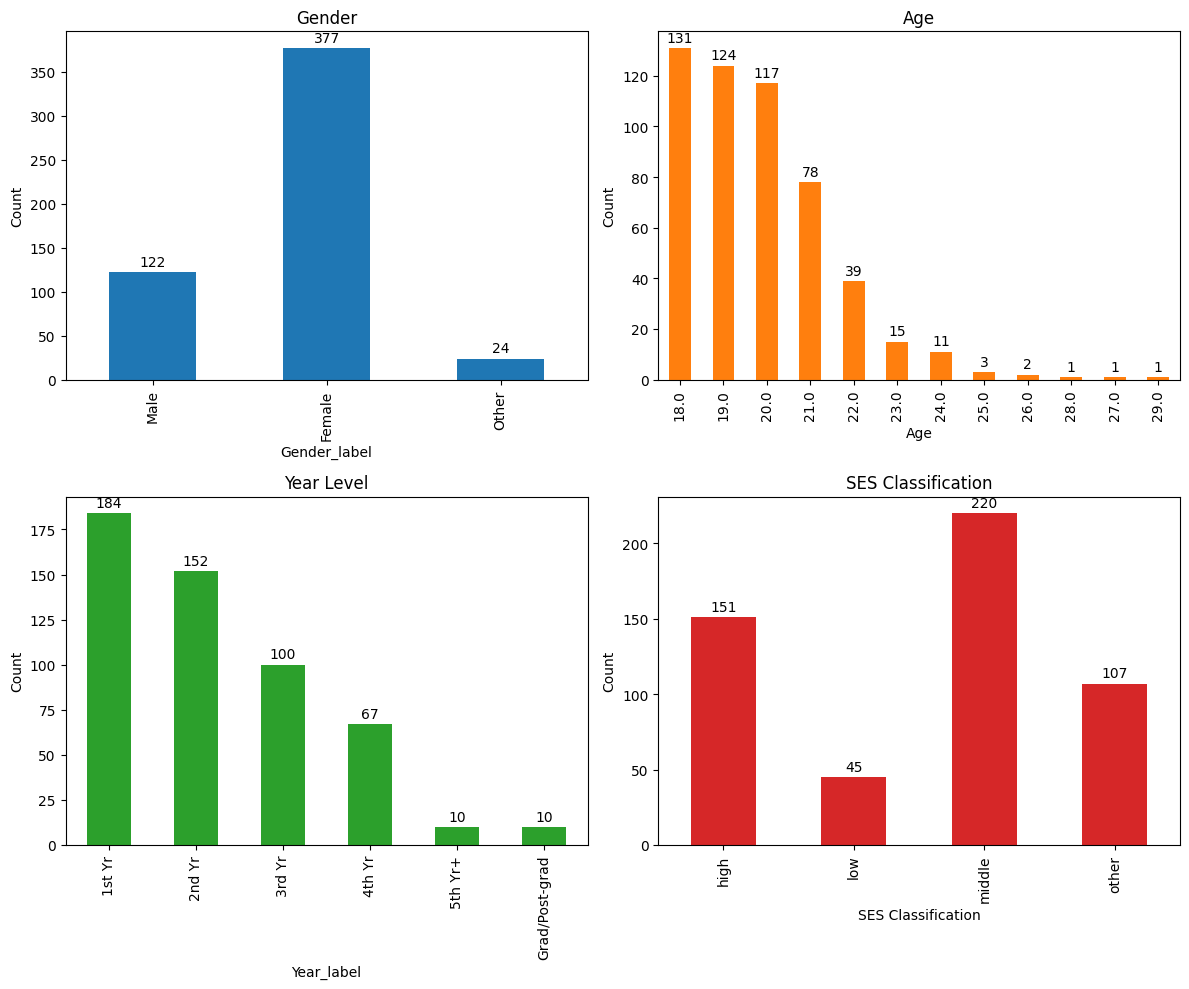

Saved as demographics_matrix.png


In [12]:
# Gender mapping
# options 3 and 4 combined as 'Other'
gender_map = {1: 'Male', 2: 'Female', 3: 'Other', 4: 'Other'}
df['Gender_label'] = df['Gender'].map(gender_map)
gender_stats_mapped = df['Gender_label'].value_counts(dropna=False).reindex(['Male', 'Female', 'Other'])

# Year Level mapping
year_map = {
    1: '1st Yr',
    2: '2nd Yr',
    3: '3rd Yr',
    4: '4th Yr',
    5: '5th Yr+', 
    6: 'Grad/Post-grad'  
}
df['Year_label'] = df['Year Level'].map(year_map)
year_stats_mapped = df['Year_label'].value_counts(dropna=False).reindex(
    ['1st Yr', '2nd Yr', '3rd Yr', '4th Yr', '5th Yr+', 'Grad/Post-grad'] 
)

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

def plot_with_labels(stats, ax, title, color):
    stats.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(stats):
        ax.text(i, v + max(stats) * 0.01, str(v), ha='center', va='bottom')

plot_with_labels(gender_stats_mapped, axes[0, 0], 'Gender', '#1f77b4')
plot_with_labels(age_dstats, axes[0, 1], 'Age', '#ff7f0e')
plot_with_labels(year_stats_mapped, axes[1, 0], 'Year Level', '#2ca02c')
plot_with_labels(ses_dstats, axes[1, 1], 'SES Classification', '#d62728')

plt.tight_layout()
plt.savefig('demographics_matrix.png', dpi=150)
plt.show()

print("Saved as demographics_matrix.png")

In [13]:
gender_pct = df['Gender_label'].value_counts(dropna=False, normalize=True).reindex(['Male', 'Female', 'Other']) * 100
age_pct = df['Age'].value_counts(dropna=False, normalize=True) * 100
year_pct = df['Year_label'].value_counts(dropna=False, normalize=True).reindex(
    ['1st Yr', '2nd Yr', '3rd Yr', '4th Yr', '5th Yr+', 'Grad/Post-grad']
) * 100
ses_pct = df['SES Classification'].value_counts(dropna=False, normalize=True).sort_index() * 100

print("Gender (%):")
print(gender_pct.round(1))

print("\nAge (%):")
print(age_pct.round(1))

print("\nYear Level (%):")
print(year_pct.round(1))

print("\nSES Classification (%):")
print(ses_pct.round(1))

Gender (%):
Gender_label
Male      23.3
Female    72.1
Other      4.6
Name: proportion, dtype: float64

Age (%):
Age
18.0    25.0
19.0    23.7
20.0    22.4
21.0    14.9
22.0     7.5
23.0     2.9
24.0     2.1
25.0     0.6
26.0     0.4
28.0     0.2
27.0     0.2
29.0     0.2
Name: proportion, dtype: float64

Year Level (%):
Year_label
1st Yr            35.2
2nd Yr            29.1
3rd Yr            19.1
4th Yr            12.8
5th Yr+            1.9
Grad/Post-grad     1.9
Name: proportion, dtype: float64

SES Classification (%):
SES Classification
high      28.9
low        8.6
middle    42.1
other     20.5
Name: proportion, dtype: float64


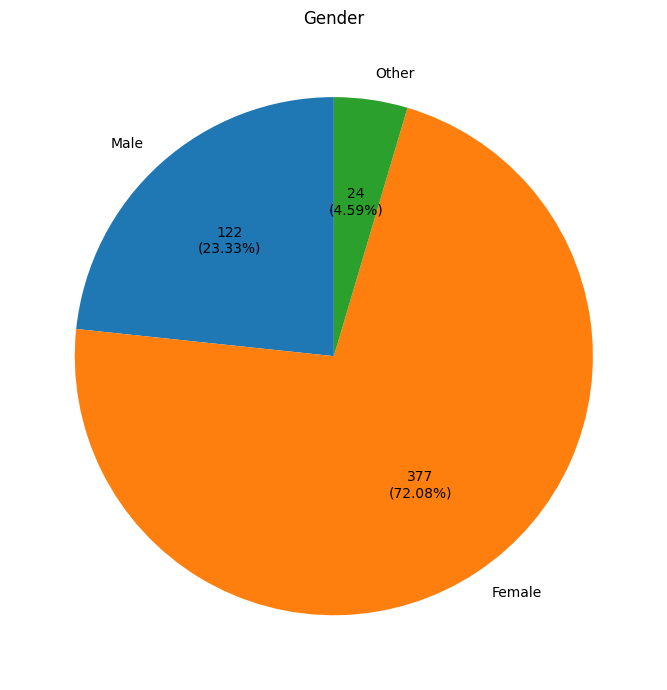

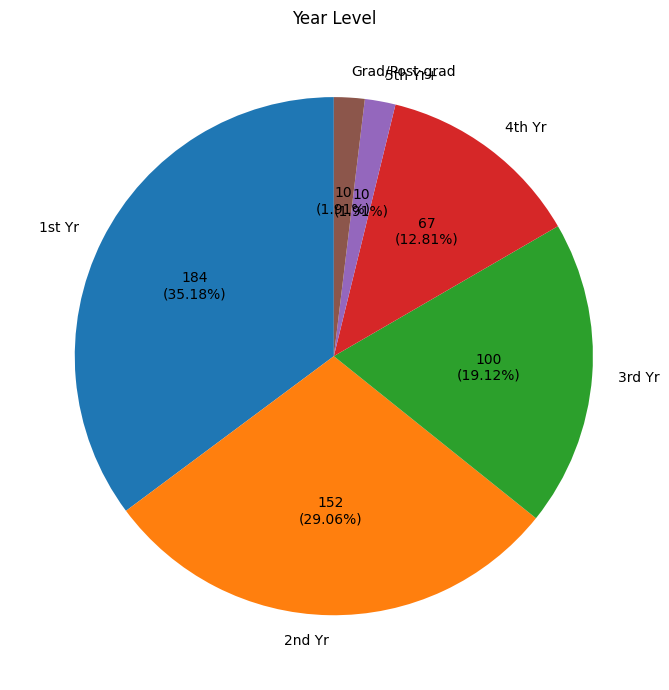

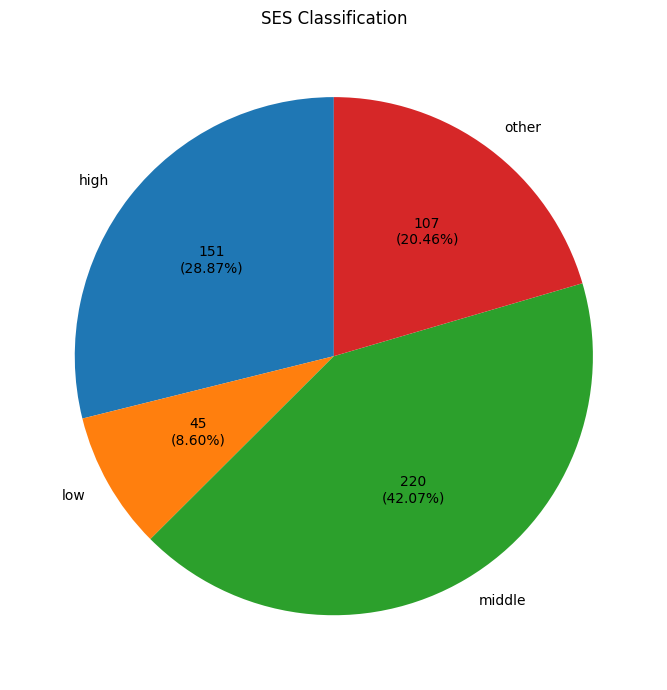

Saved: gender_piechart.png, year_level_piechart.png, ses_piechart.png


In [14]:
gender_counts = df['Gender_label'].value_counts(dropna=False).reindex(['Male', 'Female', 'Other'])
year_counts = df['Year_label'].value_counts(dropna=False).reindex(
    ['1st Yr', '2nd Yr', '3rd Yr', '4th Yr', '5th Yr+', 'Grad/Post-grad']
)
ses_counts = df['SES Classification'].value_counts(dropna=False).sort_index()

def label_fmt(counts):
    """Returns a function that formats pie slice labels as 'count\n(pct%)'."""
    def format(pct):
        count = int(round(pct / 100 * counts.sum()))
        return f'{count}\n({pct:.2f}%)'
    return format

# Gender Pie
fig1, ax1 = plt.subplots(figsize=(7, 7))
gender_counts.plot(kind='pie', ax=ax1, autopct=label_fmt(gender_counts), startangle=90)
ax1.set_title('Gender')
ax1.set_ylabel('')
plt.tight_layout()
plt.savefig('gender_piechart.png', dpi=150)
plt.show()

# Year Level Pie
fig2, ax2 = plt.subplots(figsize=(9, 7))
ax2.pie(year_counts, labels=year_counts.index, autopct=label_fmt(year_counts), startangle=90)
ax2.set_title('Year Level')
plt.tight_layout()
plt.savefig('year_level_piechart.png', dpi=150)
plt.show()

# SES Pie
fig3, ax3 = plt.subplots(figsize=(7, 7))
ses_counts.plot(kind='pie', ax=ax3, autopct=label_fmt(ses_counts), startangle=90)
ax3.set_title('SES Classification')
ax3.set_ylabel('')
plt.tight_layout()
plt.savefig('ses_piechart.png', dpi=150)
plt.show()

print("Saved: gender_piechart.png, year_level_piechart.png, ses_piechart.png")

In [15]:
#Composite Scores for Dependency Scope, Dependency Centrality, and Media Literacy

# Dependency scope scale into a composite score of 1 to 5. Likert is already 1-5.
dep_items = ["DEP1","DEP2","DEP3","DEP4","DEP5","DEP6"]                  # specify questions included
df[dep_items] = df[dep_items].apply(pd.to_numeric, errors="coerce")      # makes sure all values are numeric
df["dep_scope_score"] = df[dep_items].mean(axis=1)                       # create composite score 1-5 by row not column

# Centrality - DEP7 rescale from 0-10 count to 1-5 score
def count_dep_centrality (cell):
    """ 
    Counts how many areas were chosen under DEP7 (between 1 and 10) 
    for each person's response. Cleans the DEP7 entry for proper coding.
    """
    if pd.isna(cell) or str(cell).strip() == "":                                 # return missing/blank cells as 0 counted centrality (nothing was chosen)
        return 0
    codes = [c.strip() for c in str(cell).split(",") if c.strip() != ""]         # cleans each entry of DEP7 for proper coding
    codes = [c for c in codes if c != "11"]                                      # excludes entries of "None of those (11)"
    return len(codes)

df["DEP7_count"] = df["DEP7"].apply(count_dep_centrality)                       # apply count_dep_centrality function to DEP7, creates new DEP7 columm
df["dep_centrality_score"] = 1 + (df["DEP7_count"] / 10) * 4                    # turns new DEP7 column cell count of 1 to 10, into a new column w/ score of 1 to 5 to match other comp scores

# Literacy (NMLS) Scale into a composite score of 1 to 5. Likert already 1-5.
nmls_items = ["FC1","FC2","FC3","FP1","FP2","FP3","CP1","CP2","CP3","CC1","CC2","CC3"]  # specify questions incuded
df[nmls_items] = df[nmls_items].apply(pd.to_numeric, errors="coerce")                   # makes sure all values are numeric
df["nmls_compscore"] = df[nmls_items].mean(axis=1)                                      # create composite score 1-5

# Verify all composite scores fall between 1 and 5 / **also shows distribution
print(df[["dep_scope_score","dep_centrality_score","nmls_compscore"]].describe().round(3))  # round up 3 decimal places for readability

       dep_scope_score  dep_centrality_score  nmls_compscore
count          523.000               523.000         523.000
mean             3.623                 3.594           4.024
std              0.651                 0.854           0.460
min              1.000                 1.000           1.417
25%              3.167                 3.000           3.750
50%              3.667                 3.800           4.083
75%              4.167                 4.200           4.333
max              5.000                 5.000           5.000


In [16]:
# Descriptive Stats of Media Dependency Centrality
dep7_counts = df['DEP7_count'].value_counts(dropna=False).sort_index()

dep_centrality_counts = df['dep_centrality_score'].value_counts(dropna=False).sort_index()

centrality_table = df.groupby('DEP7_count', dropna=False)['dep_centrality_score'].agg(['first', 'count'])
centrality_table.columns = ['dep_centrality_score', 'n']
print(centrality_table)

            dep_centrality_score   n
DEP7_count                          
0                            1.0   1
1                            1.4   5
2                            1.8   7
3                            2.2  30
4                            2.6  53
5                            3.0  87
6                            3.4  78
7                            3.8  81
8                            4.2  73
9                            4.6  63
10                           5.0  45


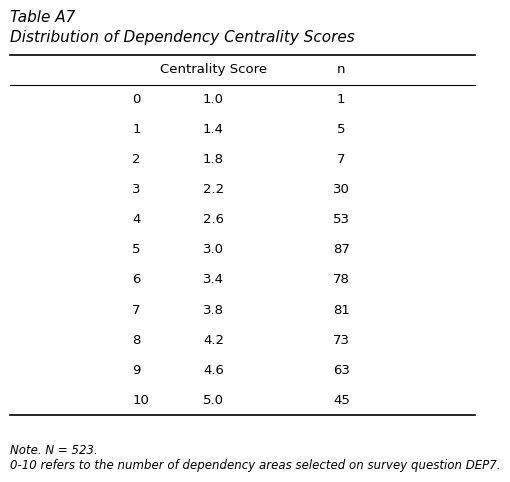

Saved: tableA7_centrality_distribution_apa.png


In [17]:
# Table A7 - Distribution of Dependency Centrality Scores (APA 7th style)

display_df = centrality_table.copy()
display_df.columns = ['Centrality Score', 'n']
display_df.index.name = 'Areas Selected'
display_df = display_df.reset_index()
display_df['Centrality Score'] = display_df['Centrality Score'].map(lambda x: f'{x:.1f}')
display_df = display_df.set_index('Areas Selected')

n_rows, n_cols = display_df.shape
fig, ax = plt.subplots(figsize=(6, 1.6 + 0.28 * n_rows))
ax.axis('off')

ax.text(0, 1 + 1.0/n_rows, 'Table A7', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1 + 0.4/n_rows, 'Distribution of Dependency Centrality Scores', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

tbl = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.30, 0, 0.55, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)

for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02

ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
header_bottom_y = 1 - (1 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

ax.text(0, -0.15,
        f'Note. N = {len(df)}. \n'
        '0-10 refers to the number of dependency areas selected on survey question DEP7.',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')

plt.savefig('tableA7_centrality_distribution_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tableA7_centrality_distribution_apa.png")

In [18]:
# Descriptive Stats of Media Dependency Scope
dep_scope_score_counts = df['dep_scope_score'].value_counts(dropna=False).sort_index()
print(dep_scope_score_counts)

dep_scope_score
1.000000     1
1.500000     1
1.666667     1
1.833333     2
2.000000     2
2.166667     5
2.333333    12
2.500000    12
2.666667    11
2.833333    26
3.000000    33
3.166667    38
3.333333    40
3.500000    54
3.666667    48
3.833333    44
4.000000    59
4.166667    47
4.333333    37
4.500000    21
4.666667    14
4.833333    12
5.000000     3
Name: count, dtype: int64


In [19]:
# Descriptive Stats of Media Literacy
nmls_compscore_counts = df['nmls_compscore'].value_counts(dropna=False).sort_index()
print(nmls_compscore_counts)

nmls_compscore
1.416667     1
2.416667     1
2.666667     1
2.750000     1
2.833333     2
2.916667     4
3.000000     2
3.083333     5
3.166667     2
3.250000     6
3.333333    20
3.416667    13
3.500000    17
3.583333    24
3.666667    22
3.750000    33
3.833333    36
3.916667    29
4.000000    34
4.083333    37
4.166667    46
4.250000    27
4.333333    33
4.416667    32
4.500000    32
4.583333    22
4.666667    13
4.750000    13
4.833333    10
4.916667     2
5.000000     3
Name: count, dtype: int64


In [20]:
# Descriptive Stats for video classification task scores

video_cols = ['VID1_DF', 'VID2_DF', 'VID3_DF', 'VID4_DF',
              'VID5_R', 'VID6_R', 'VID7_R', 'VID8_R']

# Separate real and deepfake videos
deepfake_videos = ['VID1_DF', 'VID2_DF', 'VID3_DF', 'VID4_DF']
real_videos = ['VID5_R', 'VID6_R', 'VID7_R', 'VID8_R']

# scores of correct/incorrect per video
for col in video_cols:
    counts = df[col].value_counts(dropna=False)
    print(counts)

# Answer code
# 2.0 = answered deepfake
# 1.0 = answered real

VID1_DF
2.0    405
1.0    118
Name: count, dtype: int64
VID2_DF
2.0    326
1.0    197
Name: count, dtype: int64
VID3_DF
2.0    358
1.0    165
Name: count, dtype: int64
VID4_DF
2.0    491
1.0     32
Name: count, dtype: int64
VID5_R
1.0    481
2.0     42
Name: count, dtype: int64
VID6_R
1.0    392
2.0    131
Name: count, dtype: int64
VID7_R
1.0    328
2.0    195
Name: count, dtype: int64
VID8_R
1.0    387
2.0    136
Name: count, dtype: int64


In [21]:
# specify correct answers
for col in deepfake_videos:
    df[f'{col}_correct'] = (df[col] == 2.0).astype(int)
for col in real_videos:
    df[f'{col}_correct'] = (df[col] == 1.0).astype(int)

# map the correct answers to a new variable
deepfake_correct_cols = [f'{col}_correct' for col in deepfake_videos]
real_correct_cols = [f'{col}_correct' for col in real_videos]

# count correct answers
df['deepfake_score'] = df[deepfake_correct_cols].sum(axis=1)
df['real_score'] = df[real_correct_cols].sum(axis=1)
df['total_score'] = df[deepfake_correct_cols + real_correct_cols].sum(axis=1)

# get the mean of correct answers
avg_deepfake = df['deepfake_score'].mean()
avg_real = df['real_score'].mean()
avg_total = df['total_score'].mean()

# print average and percent
print(f"Deepfake videos: {avg_deepfake:.2f} out of 4 ({avg_deepfake/4*100:.1f}%)")
print(f"Real videos:     {avg_real:.2f} out of 4 ({avg_real/4*100:.1f}%)")
print(f"Overall:         {avg_total:.2f} out of 8 ({avg_total/8*100:.1f}%)")

Deepfake videos: 3.02 out of 4 (75.5%)
Real videos:     3.04 out of 4 (75.9%)
Overall:         6.06 out of 8 (75.7%)


In [22]:
# Video Classification Descriptive Stats Table

def make_video_table(video_list):
    """creates a descriptive stats table for deepfake/real videos correct count and percent"""
    return pd.DataFrame(
        [[df[f'{col}_correct'].sum() for col in video_list],          # raw number correct
         [df[f'{col}_correct'].mean() * 100 for col in video_list]],  # percent correct
        index=['Count Correct', '% Correct'],
        columns=video_list
    ).round(1)

deepfake_video_table = make_video_table(deepfake_videos)
real_video_table = make_video_table(real_videos)

print("Deepfake Videos:")
print(deepfake_video_table)
print("\nReal Videos:")
print(real_video_table)

Deepfake Videos:
               VID1_DF  VID2_DF  VID3_DF  VID4_DF
Count Correct    405.0    326.0    358.0    491.0
% Correct         77.4     62.3     68.5     93.9

Real Videos:
               VID5_R  VID6_R  VID7_R  VID8_R
Count Correct   481.0   392.0   328.0   387.0
% Correct        92.0    75.0    62.7    74.0


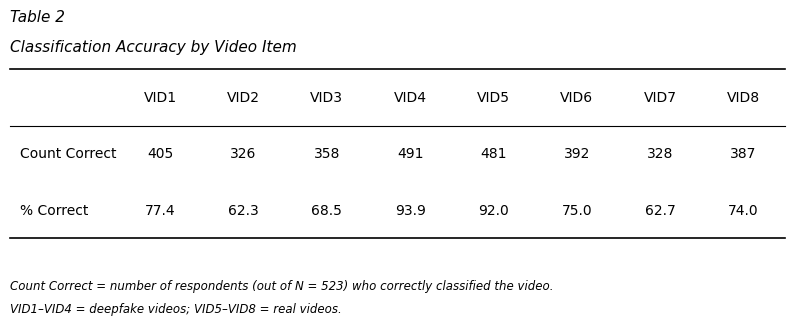

Saved: table2_video_accuracy_apa.png


In [ ]:
# Table 2 - Video Classification Accuracy by Item (APA 7th style)

combined_video_table = pd.concat([deepfake_video_table, real_video_table], axis=1)

col_labels = ['VID1', 'VID2', 'VID3', 'VID4', 'VID5', 'VID6', 'VID7', 'VID8']
row_labels = ['Count Correct', '% Correct']

vals = combined_video_table.values.astype(object)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        if row_labels[i] == 'Count Correct':
            vals[i, j] = f'{int(vals[i, j])}'
        else:
            vals[i, j] = f'{vals[i, j]:.1f}'

fig, ax = plt.subplots(figsize=(10, 2.2))
ax.axis('off')

ax.text(0, 1.28, 'Table 2', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1.10, 'Classification Accuracy by Video Item', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

n_rows, n_cols = vals.shape

tbl = ax.table(
    cellText=vals,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0.14, 0, 0.86, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)

for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02

ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
header_bottom_y = 1 - (1 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

ax.text(0, -0.30,
        'Count Correct = number of respondents (out of N = 523) who correctly classified the video.',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, -0.44,
        'VID1–VID4 = deepfake videos; VID5–VID8 = real videos.',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')

plt.savefig('table2_video_accuracy_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: table2_video_accuracy_apa.png")

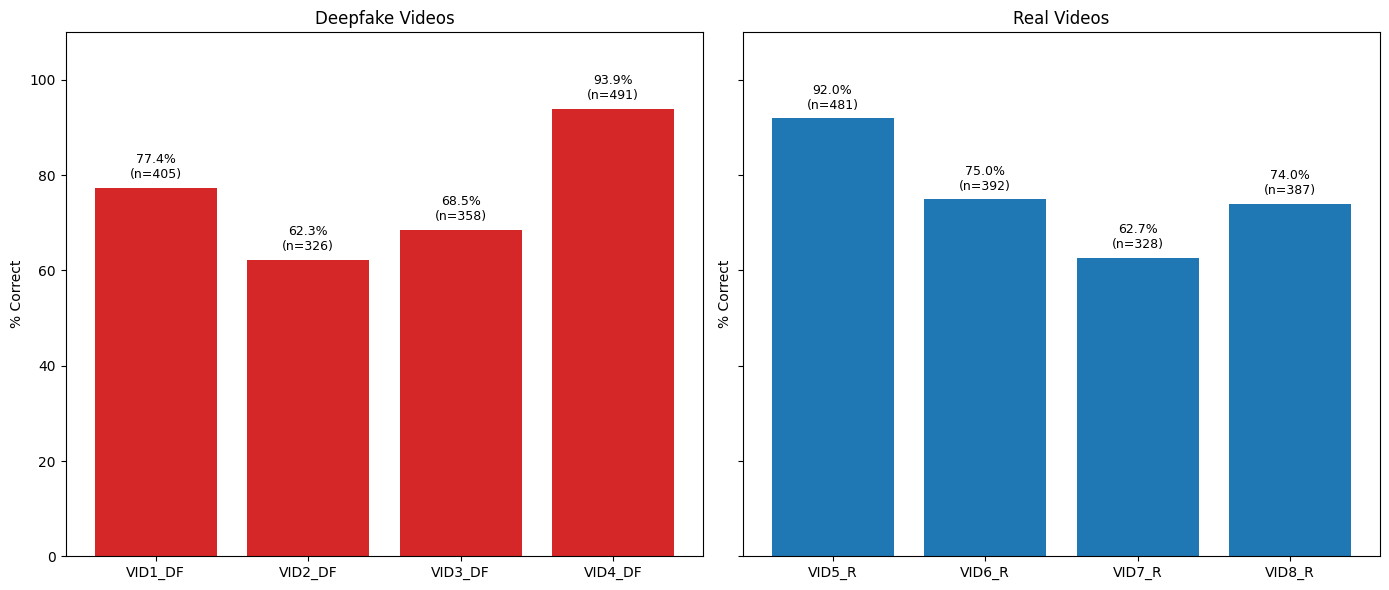

In [24]:
# Visual Table for Descriptive Stats of Video Classification Scores

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, table, title, color in [
    (axes[0], deepfake_video_table, 'Deepfake Videos', '#d62728'),
    (axes[1], real_video_table, 'Real Videos', '#1f77b4'),
]:
    pcts = table.loc['% Correct']
    counts = table.loc['Count Correct']
    bars = ax.bar(table.columns, pcts, color=color)
    ax.set_title(title)
    ax.set_ylim(0, 110)
    ax.set_ylabel('% Correct')
    for bar, p, c in zip(bars, pcts, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, p + 2,
                f'{p}%\n(n={int(c)})', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('video_accuracy.png', dpi=150)
plt.show()

In [25]:
# Table for percent correct per video

results_df = pd.concat([deepfake_video_table.loc['% Correct'], real_video_table.loc['% Correct']]).reset_index()
results_df.columns = ['Video', 'Percent Correct']
results_df['Type'] = ['Deepfake' if v in deepfake_videos else 'Real' for v in results_df['Video']]
print(results_df)

     Video  Percent Correct      Type
0  VID1_DF             77.4  Deepfake
1  VID2_DF             62.3  Deepfake
2  VID3_DF             68.5  Deepfake
3  VID4_DF             93.9  Deepfake
4   VID5_R             92.0      Real
5   VID6_R             75.0      Real
6   VID7_R             62.7      Real
7   VID8_R             74.0      Real


In [26]:
# Table of count per score + percentage of sample

counts = df['total_score'].value_counts().reindex(range(9), fill_value=0)
total_dist = pd.DataFrame({
    'Count': counts,
    'Percent': (counts / len(df) * 100).round(1)
})
total_dist.index.name = 'Score out of 8'
total_dist.loc['Total'] = [total_dist['Count'].sum(), total_dist['Percent'].sum()]
print(total_dist)

                Count  Percent
Score out of 8                
0                 0.0      0.0
1                 0.0      0.0
2                 2.0      0.4
3                25.0      4.8
4                46.0      8.8
5                98.0     18.7
6               132.0     25.2
7               137.0     26.2
8                83.0     15.9
Total           523.0    100.0


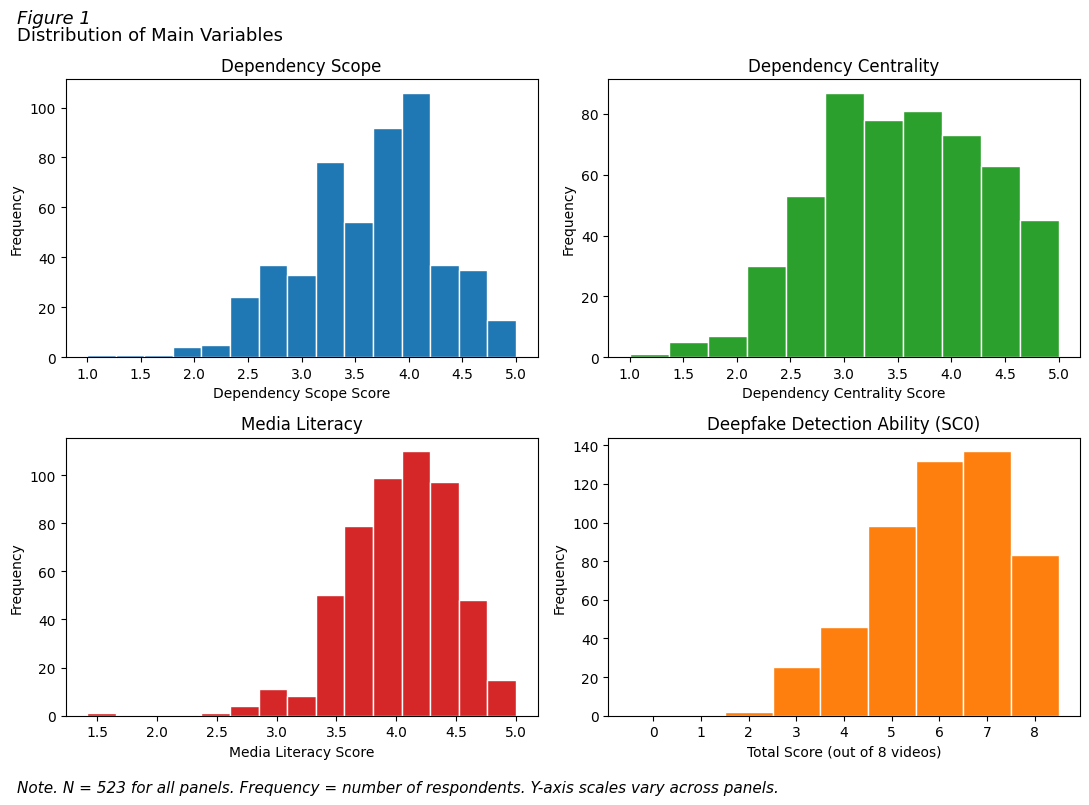

Saved: figure1_all_histograms_grid.png


In [27]:
# Figure 1 - Distribution of Main Study Variables

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

fig.suptitle('Figure 1', fontsize=13, fontstyle='italic', x=0.02, y=0.90, ha='left')
fig.text(0.02, 0.865, 'Distribution of Main Variables', fontsize=13, ha='left')

axes[0, 0].hist(df['dep_scope_score'].dropna(), bins=15, color='#1f77b4', edgecolor='white')
axes[0, 0].set_xlabel('Dependency Scope Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Dependency Scope')

axes[0, 1].hist(df['dep_centrality_score'].dropna(), bins=11, color='#2ca02c', edgecolor='white')
axes[0, 1].set_xlabel('Dependency Centrality Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Dependency Centrality')

axes[1, 0].hist(df['nmls_compscore'].dropna(), bins=15, color='#d62728', edgecolor='white')
axes[1, 0].set_xlabel('Media Literacy Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Media Literacy')

axes[1, 1].hist(df['total_score'].dropna(), bins=9, range=(-0.5, 8.5), color='#ff7f0e', edgecolor='white')
axes[1, 1].set_xlabel('Total Score (out of 8 videos)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xticks(range(0, 9))
axes[1, 1].set_title('Deepfake Detection Ability (SC0)')

fig.text(0.02, 0.03,
         'Note. N = 523 for all panels. Frequency = number of respondents. Y-axis scales vary across panels.',
         fontsize=11, fontstyle='italic', ha='left')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.savefig('figure1_all_histograms_grid.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figure1_all_histograms_grid.png")

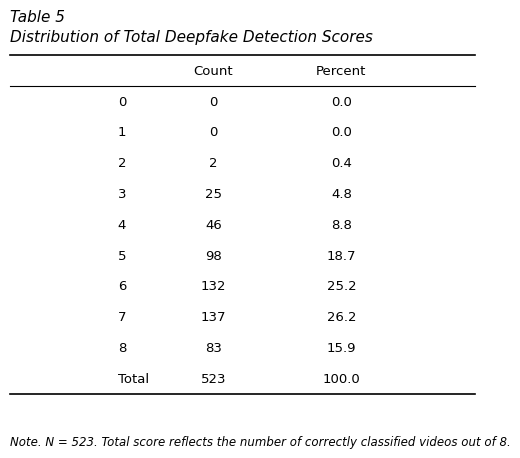

Saved: table5_total_score_distribution_apa.png


In [28]:
# Table 5 - Distribution of Total Deepfake Detection Scores (APA 7th style)

counts = df['total_score'].value_counts().reindex(range(9), fill_value=0)
total_dist = pd.DataFrame({
    'Count': counts,
    'Percent': (counts / len(df) * 100).round(1)
})
total_dist.index.name = 'Score out of 8'
total_dist.loc['Total'] = [total_dist['Count'].sum(), total_dist['Percent'].sum()]

display_df = total_dist.copy()
display_df['Count'] = display_df['Count'].map(lambda x: f'{int(x)}')
display_df['Percent'] = display_df['Percent'].map(lambda x: f'{x:.1f}')

n_rows, n_cols = display_df.shape
fig, ax = plt.subplots(figsize=(6, 1.6 + 0.28 * n_rows))
ax.axis('off')

ax.text(0, 1 + 1.0/n_rows, 'Table 5', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1 + 0.4/n_rows, 'Distribution of Total Deepfake Detection Scores', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

tbl = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.30, 0, 0.55, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)

for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02

ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
header_bottom_y = 1 - (1 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

note_y = -0.15
ax.text(0, note_y,
        f'Note. N = {len(df)}. Total score reflects the number of correctly classified videos out of 8.',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')

plt.savefig('table5_total_score_distribution_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: table5_total_score_distribution_apa.png")

In [29]:
# Table for Deepfake/Real Score Distribution

dcounts = df['deepfake_score'].value_counts().reindex(range(5), fill_value=0)
rcounts = df['real_score'].value_counts().reindex(range(5), fill_value=0)

split_dist = pd.DataFrame({
    'Deepfake Count': dcounts,
    'Deepfake %': (dcounts / len(df) * 100).round(1),
    'Real Count': rcounts,
    'Real %': (rcounts / len(df) * 100).round(1),
})
split_dist.index.name = 'Score out of 4'

split_dist.loc['Total'] = [
    split_dist['Deepfake Count'].sum(),
    split_dist['Deepfake %'].sum(),
    split_dist['Real Count'].sum(),
    split_dist['Real %'].sum(),
]
print(split_dist)

                Deepfake Count  Deepfake %  Real Count  Real %
Score out of 4                                                
0                          0.0         0.0         1.0     0.2
1                         36.0         6.9        34.0     6.5
2                        105.0        20.1       105.0    20.1
3                        194.0        37.1       188.0    35.9
4                        188.0        35.9       195.0    37.3
Total                    523.0       100.0       523.0   100.0


In [30]:
# SES HANDLING FOR OFW AMBIGUITY

#Filter out 'other' in SES - comparison checks w and w/o SES to be done later
df_ses = df[(df['SES Classification'] != "other")].copy()   # .copy() to prevent df to df_ses leaks in changes

#Current count of entries
print("Complete df entry count:", len(df))
print("Filtered df (df_ses) entry count:", len(df_ses))

Complete df entry count: 523
Filtered df (df_ses) entry count: 416


In [31]:
#Check composite scores for both, full df and filtered SES df
print("Full df composites:")
print(df[["dep_scope_score","dep_centrality_score","nmls_compscore"]].describe().round(3))
print("\ndf_ses composites:")
print(df_ses[["dep_scope_score","dep_centrality_score","nmls_compscore"]].describe().round(3))

Full df composites:
       dep_scope_score  dep_centrality_score  nmls_compscore
count          523.000               523.000         523.000
mean             3.623                 3.594           4.024
std              0.651                 0.854           0.460
min              1.000                 1.000           1.417
25%              3.167                 3.000           3.750
50%              3.667                 3.800           4.083
75%              4.167                 4.200           4.333
max              5.000                 5.000           5.000

df_ses composites:
       dep_scope_score  dep_centrality_score  nmls_compscore
count          416.000               416.000         416.000
mean             3.642                 3.602           4.035
std              0.628                 0.845           0.439
min              1.500                 1.400           2.667
25%              3.167                 3.000           3.750
50%              3.667                 3.400 

In [32]:
#PRE-ANALYSIS CHECKS (multicollinearity and outliers)

#Multicollinearity check for Media Dependency Scope, Media Dependency Centrality, and Media Literacy

def calculate_vif(df):
    """
    Calculate Variance Inflation Factor (VIF) for each feature in the DataFrame.
    Only numeric columns are considered.
    """
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.empty:
        raise ValueError("No numeric columns found for VIF calculation.")

    # Add constant for intercept
    X = sm.add_constant(numeric_df)

    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_data

main_indicators = df_ses[["dep_scope_score","dep_centrality_score","nmls_compscore"]]

# Calculate VIF of main indicators
vif_df = calculate_vif(main_indicators)

print("\nVIF Results:")
print(vif_df)


VIF Results:
                Feature         VIF
0                 const  103.387571
1       dep_scope_score    1.116275
2  dep_centrality_score    1.164653
3        nmls_compscore    1.095918


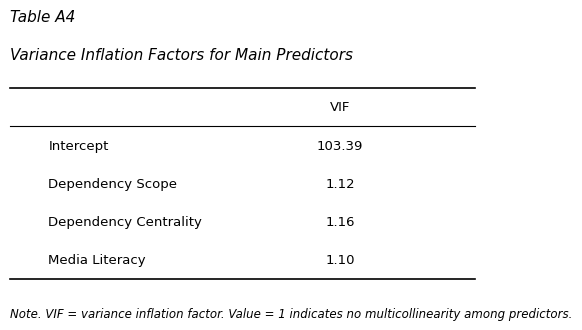

Saved: tableA4_vif_apa.png


In [33]:
# Table A4 - Variance Inflation Factors for Main Predictors (APA 7th style)

vif_display = vif_df.copy()
vif_display['Feature'] = vif_display['Feature'].replace({
    'const': 'Intercept',
    'dep_scope_score': 'Dependency Scope',
    'dep_centrality_score': 'Dependency Centrality',
    'nmls_compscore': 'Media Literacy'
})
vif_display = vif_display.set_index('Feature')
vif_display['VIF'] = vif_display['VIF'].map(lambda x: f'{x:.2f}')

n_rows, n_cols = vif_display.shape
fig, ax = plt.subplots(figsize=(6, 1.2 + 0.32 * n_rows))
ax.axis('off')

ax.text(0, 1 + 1.4/n_rows, 'Table A4', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1 + 0.6/n_rows, 'Variance Inflation Factors for Main Predictors', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

tbl = ax.table(
    cellText=vif_display.values,
    rowLabels=vif_display.index,
    colLabels=vif_display.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.42, 0, 0.58, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)

for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02

ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
header_bottom_y = 1 - (1 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

note_y = -0.16 * (5 / n_rows)
ax.text(0, note_y,
        'Note. VIF = variance inflation factor. Value = 1 indicates no multicollinearity '
        'among predictors.',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')

plt.savefig('tableA4_vif_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tableA4_vif_apa.png")

In [ ]:
#Check for Outliers in Data using Mahalanobis Distance

def mahalanobis_distances(X):
    """
    Compute Mahalanobis distances for each observation in X.
    X: 2D numpy array or DataFrame (rows = observations, cols = variables)
    """
    if isinstance(X, pd.DataFrame):
        X = X.values  # Convert to numpy array
    
    # Mean vector
    mean_vec = np.mean(X, axis=0)
    
    # Covariance matrix and its inverse
    cov_matrix = np.cov(X, rowvar=False)
    try:
        inv_cov_matrix = inv(cov_matrix)
    except np.linalg.LinAlgError:
        raise ValueError("Covariance matrix is singular. Check for collinearity.")
    
    # Compute Mahalanobis distance for each observation
    diff = X - mean_vec
    left_term = np.dot(diff, inv_cov_matrix)
    mahal = np.sqrt(np.sum(left_term * diff, axis=1))
    return mahal

def detect_outliers_mahalanobis(X, alpha=0.001):
    """
    Detect outliers using Mahalanobis distance.
    alpha: significance level (smaller = stricter)
    """
    m_dist = mahalanobis_distances(X)
    dof = X.shape[1]  # dof is degrees of freedom (not dataframe) = number of variables
    chi2_threshold = np.sqrt(chi2.ppf((1 - alpha), dof))
    outliers = np.where(m_dist > chi2_threshold)[0]
    return m_dist, outliers, chi2_threshold

# apply dataframe, define group of main indicators
main_indicators = df_ses[["dep_scope_score","dep_centrality_score","nmls_compscore"]]

m_dist, outliers, threshold = detect_outliers_mahalanobis(main_indicators, alpha=0.001)

# Print results if outliers present
print(f"Chi-square threshold (alpha=0.001, df={main_indicators.shape[1]}): {threshold:.3f}")  # threshold for classifying an outlier
print(f"Number of multivariate outliers: {len(outliers)}")                                    # shows how many outliers present  
print("\nOutlier rows:")                                                                      # shows outlier location in df          
print(main_indicators.iloc[outliers])

# See the outlier's distance from everyone else
print("\nTheir Mahalanobis distances:")
print(pd.Series(m_dist).iloc[outliers].round(3))

Chi-square threshold (alpha=0.001, df=3): 4.033
Number of multivariate outliers: 0

Outlier rows:
Empty DataFrame
Columns: [dep_scope_score, dep_centrality_score, nmls_compscore]
Index: []

Their Mahalanobis distances:
Series([], dtype: float64)


In [35]:
# Cronbach's alpha

# not needed for centrality since only one question
dep_alpha = pg.cronbach_alpha(data=df[dep_items].dropna())
nmls_alpha = pg.cronbach_alpha(data=df[nmls_items].dropna())

# confirm sample size, no ones dropped
dep_n = len(df[dep_items].dropna())
nmls_n = len(df[nmls_items].dropna())

print(f"Dependency Scope ({len(dep_items)} items, n={dep_n}): "
      f"alpha = {dep_alpha[0]:.3f}, 95% CI [{dep_alpha[1][0]:.3f}, {dep_alpha[1][1]:.3f}]")
print(f"NMLS ({len(nmls_items)} items, n={nmls_n}): "
      f"alpha = {nmls_alpha[0]:.3f}, 95% CI [{nmls_alpha[1][0]:.3f}, {nmls_alpha[1][1]:.3f}]")

Dependency Scope (6 items, n=523): alpha = 0.741, 95% CI [0.705, 0.774]
NMLS (12 items, n=523): alpha = 0.752, 95% CI [0.719, 0.782]


In [36]:
# MAIN OLS ANALYSIS

# Model1 - without SES variable (using filtered df_ses: 'Other' group is excluded in df, N=416)
# Model2 - with SES variable (using filtered df_ses: 'Other' group is excluded in df, N=416)
# Model3 - without SES variable using full df - 'Other' group included in df, N-523

# Model1 - without SES variable (using filtered df_ses: 'Other' group is excluded in df)
model1 = smf.ols(                                       
    "SC0 ~ dep_scope_score + dep_centrality_score + nmls_compscore "        # specify outcome var, main indicators, and controls to fit to OLS
    "+ C(Gender_label) + Age + C(Q('Year Level'))",
    data=df_ses                                                     # specify which dataframe to use
).fit()
print(model1.summary())                                             # print results

                            OLS Regression Results                            
Dep. Variable:                    SC0   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9447
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.497
Time:                        14:00:15   Log-Likelihood:                -726.81
No. Observations:                 416   AIC:                             1478.
Df Residuals:                     404   BIC:                             1526.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [37]:
# Model2 - with SES variable (using filtered df_ses: 'Other' group is excluded in df)

model2 = smf.ols(
    "SC0 ~ dep_scope_score + dep_centrality_score + nmls_compscore "
    "+ C(Gender_label) + Age + C(Q('Year Level')) + C(Q('SES Classification'))",
    data=df_ses
).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                    SC0   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.8563
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.600
Time:                        14:00:15   Log-Likelihood:                -726.41
No. Observations:                 416   AIC:                             1481.
Df Residuals:                     402   BIC:                             1537.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


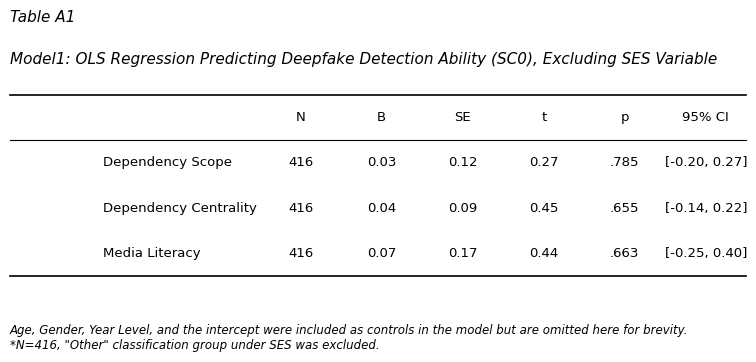

Saved: tableA1_model1_apa.png


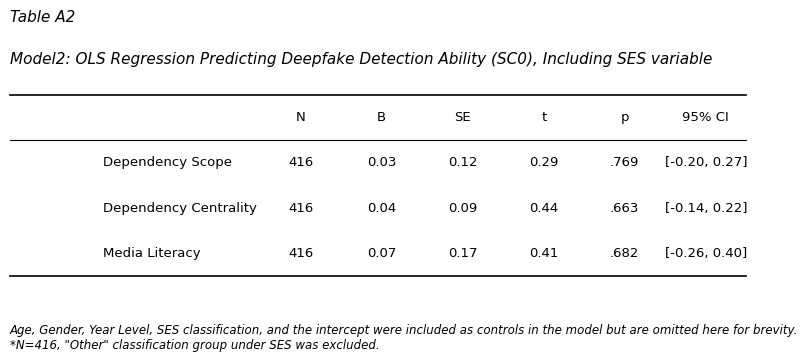

Saved: tableA2_model2_apa.png


In [ ]:
# Function for printing APA-style OLS results table
# Table A1 + Table A2

def make_apa_ols_table(model, table_num, title, keep_vars, name_map, filename, controls_note):
    ci = model.conf_int()
    ci.columns = ['CI_lower', 'CI_upper']

    results_df = pd.DataFrame({
        'B': model.params,
        'SE': model.bse,
        't': model.tvalues,
        'p': model.pvalues,
        'CI_lower': ci['CI_lower'],
        'CI_upper': ci['CI_upper']
    }).loc[keep_vars]

    results_df.index = [name_map.get(idx, idx) for idx in results_df.index]

    def fmt_p(p):
        return '< .001' if p < .001 else f'{p:.3f}'.lstrip('0') if p < 1 else f'{p:.3f}'

    display_df = pd.DataFrame({
        'N': [int(model.nobs)] * len(results_df),
        'B': results_df['B'].map(lambda x: f'{x:.2f}'),
        'SE': results_df['SE'].map(lambda x: f'{x:.2f}'),
        't': results_df['t'].map(lambda x: f'{x:.2f}'),
        'p': results_df['p'].map(fmt_p),
        '95% CI': results_df.apply(lambda r: f"[{r['CI_lower']:.2f}, {r['CI_upper']:.2f}]", axis=1)
    })

    n_rows, n_cols = display_df.shape
    fig, ax = plt.subplots(figsize=(9.5, 1.4 + 0.32 * n_rows))
    ax.axis('off')

    ax.text(0, 1 + 1.2/n_rows, f'Table {table_num}', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
    ax.text(0, 1 + 0.5/n_rows, title, fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

    tbl = ax.table(
        cellText=display_df.values,
        rowLabels=display_df.index,
        colLabels=display_df.columns,
        cellLoc='center',
        loc='center',
        bbox=[0.34, 0, 0.66, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)

    for key, cell in tbl.get_celld().items():
        cell.set_linewidth(0)

    for row_idx in range(n_rows):
        tbl[row_idx + 1, -1].get_text().set_ha('left')
        tbl[row_idx + 1, -1].PAD = 0.02

    ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
    header_bottom_y = 1 - (1 / (n_rows + 1))
    ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
    ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

    note_y = -0.12 * (10 / n_rows)
    ax.text(0, note_y,
            controls_note,
            fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')

    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


base_name_map = {
    'dep_scope_score': 'Dependency Scope',
    'dep_centrality_score': 'Dependency Centrality',
    'nmls_compscore': 'Media Literacy',
}
keep_vars = list(base_name_map.keys())

# Table A1 - Model 1 (df_ses, excluding SES "other")
make_apa_ols_table(
    model1, 'A1',
    'Model1: OLS Regression Predicting Deepfake Detection Ability (SC0), Excluding SES Variable',
    keep_vars, base_name_map,
    'tableA1_model1_apa.png',
    controls_note='Age, Gender, Year Level, and the intercept were included as controls in the model but are omitted here for brevity.\n' \
    '*N=416, "Other" classification group under SES was excluded.'
)

# Table A2 - Model 2 (df_ses, controlling for SES)
make_apa_ols_table(
    model2, 'A2',
    'Model2: OLS Regression Predicting Deepfake Detection Ability (SC0), Including SES variable',
    keep_vars, base_name_map,
    'tableA2_model2_apa.png',
    controls_note='Age, Gender, Year Level, SES classification, and the intercept were included as controls in the model but are omitted here for brevity.\n' \
    '*N=416, "Other" classification group under SES was excluded.'
)

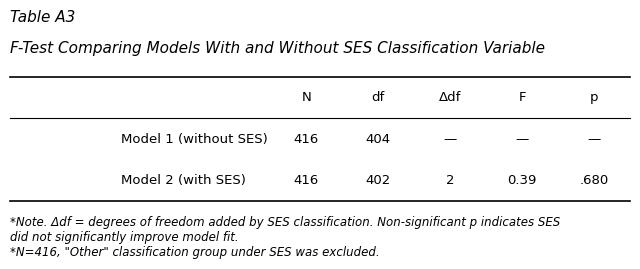

Saved: tableA3_ses_ftest_apa.png


In [39]:
# Table A3 - Model Comparison — F-test for SES Contribution (APA 7th style)
from statsmodels.stats.anova import anova_lm
f_test = anova_lm(model1, model2)  # main test
df_resid_2 = f_test.loc[1, 'df_resid']
df_diff = f_test.loc[1, 'df_diff']
f_stat = f_test.loc[1, 'F']
p_val = f_test.loc[1, 'Pr(>F)']
def fmt_p(p):
    return '< .001' if p < .001 else f'{p:.3f}'.lstrip('0')
comparison_data = [
    ['Model 1 (without SES)', f'{int(model1.nobs)}', f'{int(f_test.loc[0, "df_resid"])}', '—', '—', '—'],
    ['Model 2 (with SES)', f'{int(model2.nobs)}', f'{int(df_resid_2)}', f'{int(df_diff)}', f'{f_stat:.2f}', fmt_p(p_val)],
]
comp_df = pd.DataFrame(comparison_data, columns=['Model', 'N', 'df', 'Δdf', 'F', 'p'])
comp_df = comp_df.set_index('Model')
fig, ax = plt.subplots(figsize=(8, 1.6))
ax.axis('off')
ax.text(0, 1.45, 'Table A3', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1.20, 'F-Test Comparing Models With and Without SES Classification Variable', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
n_rows, n_cols = comp_df.shape
tbl = ax.table(
    cellText=comp_df.values,
    rowLabels=comp_df.index,
    colLabels=comp_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.42, 0, 0.58, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)
for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02
ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
header_bottom_y = 1 - (1 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
ax.text(0, -0.45,
        '*Note. Δdf = degrees of freedom added by SES classification. Non-significant p indicates SES \n'
        'did not significantly improve model fit.\n'
        '*N=416, "Other" classification group under SES was excluded.',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')
plt.savefig('tableA3_ses_ftest_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tableA3_ses_ftest_apa.png")

In [40]:
# F-test comparing Model 1 (no SES) vs Model 2 (with SES)
from statsmodels.stats.anova import anova_lm

f_test = anova_lm(model1, model2)
print(f_test)

   df_resid         ssr  df_diff   ss_diff         F    Pr(>F)
0     404.0  801.987063      0.0       NaN       NaN       NaN
1     402.0  800.450430      2.0  1.536633  0.385862  0.680116


In [41]:
# PRIMARY MODEL
# MODEL 3 — with no SES (using complete df since SES not significant in Model 1&2)
model3 = smf.ols(
    "SC0 ~ dep_scope_score + dep_centrality_score + nmls_compscore "
    "+ C(Gender_label) + Age + C(Q('Year Level'))",
    data=df
).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    SC0   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.162
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.311
Time:                        14:00:16   Log-Likelihood:                -906.78
No. Observations:                 523   AIC:                             1838.
Df Residuals:                     511   BIC:                             1889.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [42]:
# Descriptive Stats with Pearson's R for Dependency Scope, Dep Centrality, Media Literacy, and Detection Ability (SC0)
desc_stats = ['SC0', 'dep_scope_score', 'dep_centrality_score', 'nmls_compscore']
print(df[desc_stats].describe().T[['count','mean','std','min','max']].round(2))
print()
print(df[desc_stats].corr().round(3))

                      count  mean   std   min  max
SC0                   523.0  6.06  1.39  2.00  8.0
dep_scope_score       523.0  3.62  0.65  1.00  5.0
dep_centrality_score  523.0  3.59  0.85  1.00  5.0
nmls_compscore        523.0  4.02  0.46  1.42  5.0

                        SC0  dep_scope_score  dep_centrality_score  \
SC0                   1.000           -0.011                -0.005   
dep_scope_score      -0.011            1.000                 0.332   
dep_centrality_score -0.005            0.332                 1.000   
nmls_compscore        0.022            0.205                 0.267   

                      nmls_compscore  
SC0                            0.022  
dep_scope_score                0.205  
dep_centrality_score           0.267  
nmls_compscore                 1.000  


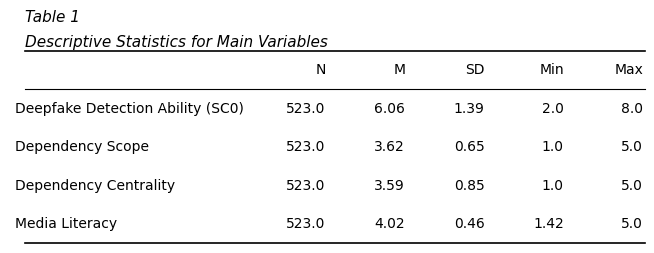

Saved: table1_descriptives_apa.png


In [59]:
# Table 1 - Descriptive Statistics (APA 7th style)

desc_stats = ['SC0', 'dep_scope_score', 'dep_centrality_score', 'nmls_compscore']
row_labels = ['Deepfake Detection Ability (SC0)', 'Dependency Scope', 'Dependency Centrality', 'Media Literacy']

desc_table = df[desc_stats].describe().T[['count','mean','std','min','max']].round(2)
desc_table.index = row_labels
desc_table.columns = ['N', 'M', 'SD', 'Min', 'Max']

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')

ax.text(0, 1.15, 'Table 1', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1.02, 'Descriptive Statistics for Main Variables', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

n_rows, n_cols = desc_table.shape
col_labels = desc_table.columns.tolist()

tbl = ax.table(
    cellText=desc_table.values,
    rowLabels=desc_table.index,
    colLabels=col_labels,
    cellLoc='right',
    loc='center',
    bbox=[0.36, 0, 0.64, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)
    cell.get_text().set_ha('right')
    cell.PAD = 0.02

for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02

tbl[0, -1].get_text().set_ha('left') if (0, -1) in tbl.get_celld() else None


ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

header_bottom_y = 1 - (1 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)

ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

plt.savefig('table1_descriptives_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: table1_descriptives_apa.png")

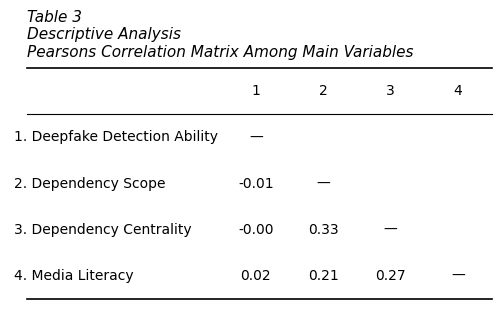

Saved: table3_correlations_apa.png


In [ ]:
# Table 3 - Descriptive Analysis, Pearson Correlation Matrix (APA 7th style)

corr_table = df[desc_stats].corr().round(2)
short_labels = ['1. Deepfake Detection Ability', '2. Dependency Scope', '3. Dependency Centrality', '4. Media Literacy']
corr_table.index = short_labels
corr_table.columns = ['1', '2', '3', '4']

vals = corr_table.values.astype(object)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        if j > i:
            vals[i, j] = ''
        elif j == i:
            vals[i, j] = '—'
        else:
            vals[i, j] = f'{vals[i, j]:.2f}'

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')

ax.text(0, 1.20, 'Table 3', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1.05, 'Descriptive Analysis \nPearsons Correlation Matrix Among Main Variables', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

n_rows, n_cols = vals.shape

tbl = ax.table(
    cellText=vals,
    rowLabels=corr_table.index,
    colLabels=corr_table.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.42, 0, 0.58, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)

for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02

ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
header_bottom_y = 1 - (1 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

plt.savefig('table3_correlations_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: table3_correlations_apa.png")

In [136]:
#Binary Log Reg - Robustness Check 

# define binary outcome: 1 = good detector (3-4 deepfake videos correct), 0 = bad detector (0-2 videos correct) 
# outcome variable set to deepfake detection score rather than overall score
df["detect_binary"] = (df["deepfake_score"] > 2).astype(int)  

# check the split
print(df["detect_binary"].value_counts())

# fit logit on full df, no SES 
logit_model = smf.logit(
    "detect_binary ~ dep_scope_score + dep_centrality_score + nmls_compscore "  # specify outcom var (detect_binary), main indicators, and controls
    "+ C(Gender_label) + Age + C(Q('Year Level'))",
    data=df                                                                     # specify df used (full df)
).fit()
print(logit_model.summary())

# odds ratios
conf = logit_model.conf_int()
conf['OR'] = logit_model.params
conf.columns = ['2.5%', '97.5%', 'OR']
odds_ratios = np.exp(conf)                           # exponentiate coef + CI bounds
odds_ratios['p-value'] = logit_model.pvalues         # p-value doesn't get exponentiated

# print results
print("\nOdds ratios with 95% CI:")                  # odds ratios for interpretation
print(odds_ratios.round(3))                          # round to 3 decimals for readability
print(f"Sample size: N={logit_model.nobs}")

detect_binary
1    382
0    141
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.576550
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          detect_binary   No. Observations:                  523
Model:                          Logit   Df Residuals:                      511
Method:                           MLE   Df Model:                           11
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                 0.01082
Time:                        14:50:07   Log-Likelihood:                -301.54
converged:                       True   LL-Null:                       -304.84
Covariance Type:            nonrobust   LLR p-value:                    0.8305
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept           

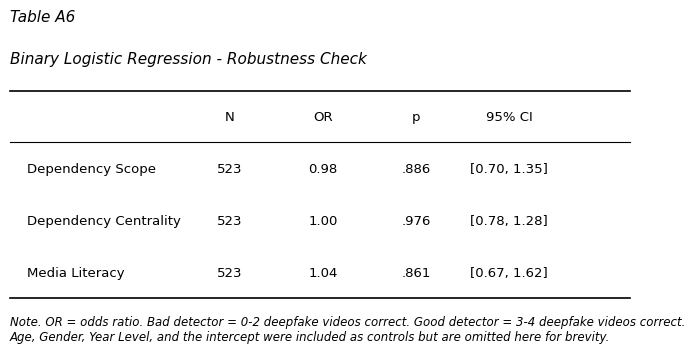

Saved: tableA6_logit_robustness_apa.png


In [137]:
# Table A6 - Logistic Regression Robustness Check — Odds Ratios (APA 7th style)

conf = logit_model.conf_int()
conf['OR'] = logit_model.params
conf.columns = ['2.5%', '97.5%', 'OR']
odds_ratios = np.exp(conf)
odds_ratios['p-value'] = logit_model.pvalues

keep_vars = ['dep_scope_score', 'dep_centrality_score', 'nmls_compscore']
name_map = {
    'dep_scope_score': 'Dependency Scope',
    'dep_centrality_score': 'Dependency Centrality',
    'nmls_compscore': 'Media Literacy',
}

results_df = odds_ratios.loc[keep_vars]
results_df.index = [name_map[idx] for idx in results_df.index]

def fmt_p(p):
    return '< .001' if p < .001 else f'{p:.3f}'.lstrip('0')

display_df = pd.DataFrame({
    'N': [int(logit_model.nobs)] * len(results_df),
    'OR': results_df['OR'].map(lambda x: f'{x:.2f}'),
    'p': results_df['p-value'].map(fmt_p),
    '95% CI': results_df.apply(lambda r: f"[{r['2.5%']:.2f}, {r['97.5%']:.2f}]", axis=1)
})

n_rows, n_cols = display_df.shape
fig, ax = plt.subplots(figsize=(8, 1.8 + 0.30 * n_rows))
ax.axis('off')

ax.text(0, 1 + 1.0/n_rows, 'Table A6', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1 + 0.4/n_rows, 'Binary Logistic Regression - Robustness Check', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

tbl = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.28, 0, 0.60, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)

for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02

ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
header_bottom_y = 1 - (1 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

note_y = -0.20
ax.text(0, note_y,
        'Note. OR = odds ratio. Bad detector = 0-2 deepfake videos correct. Good detector = 3-4 deepfake videos correct. \n'
        'Age, Gender, Year Level, and the intercept were included as controls but are omitted here for brevity.',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')

plt.savefig('tableA6_logit_robustness_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tableA6_logit_robustness_apa.png")

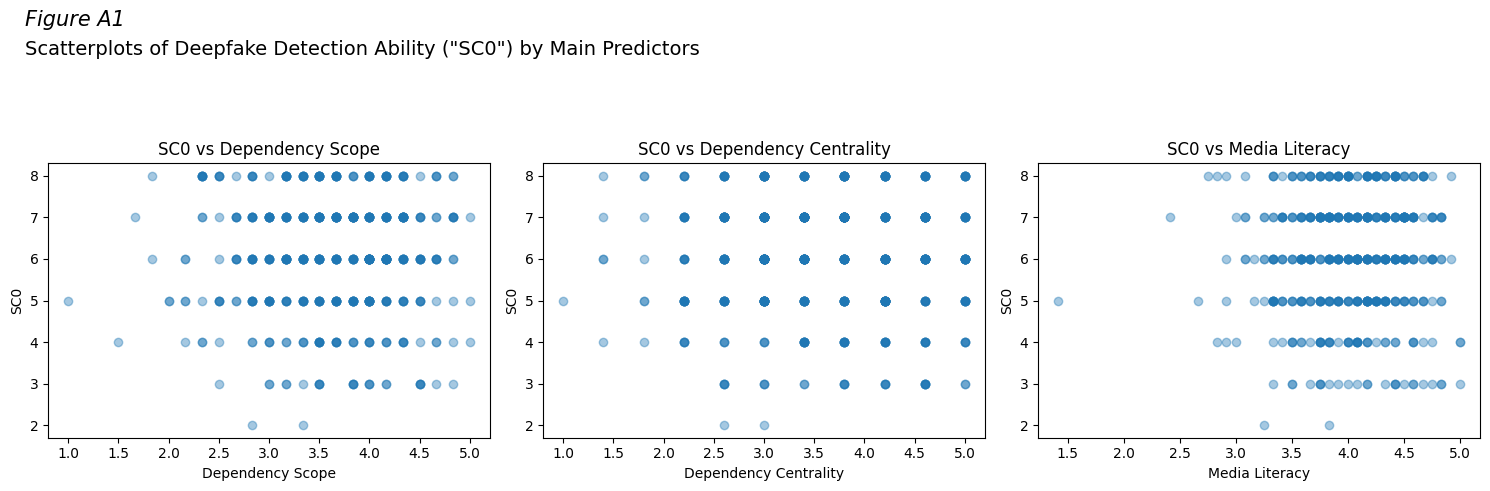

Saved: figureA1_linearity_scatterplots.png


In [138]:
# Figure A1
# Visual for Linearity Graph

predictors = ['dep_scope_score', 'dep_centrality_score', 'nmls_compscore']
pred_labels = ['Dependency Scope', 'Dependency Centrality', 'Media Literacy']

fig, axes = plt.subplots(1, len(predictors), figsize=(15, 4.5))

fig.suptitle('Figure A1', fontsize=15, fontstyle='italic', x=0.02, y=1.08, ha='left')
fig.text(0.02, 0.98, 'Scatterplots of Deepfake Detection Ability ("SC0") by Main Predictors', fontsize=14, ha='left')

for i, pred in enumerate(predictors):
    axes[i].scatter(df[pred], df['SC0'], alpha=0.4)
    axes[i].set_xlabel(pred_labels[i])
    axes[i].set_ylabel('SC0')
    axes[i].set_title(f'SC0 vs {pred_labels[i]}')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('figureA1_linearity_scatterplots.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figureA1_linearity_scatterplots.png")

In [139]:
# Numerical Test for Linearity Assumption - RESET

reset_result = linear_reset(model3, power=2, use_f=True)
print(f"RESET Test: F-statistic = {reset_result.fvalue:.3f}, p-value = {reset_result.pvalue:.3f}")

RESET Test: F-statistic = 0.894, p-value = 0.345


In [140]:
# Secondary Numerical Test for Linearity Assumption - Rainbow Test

stat, p_value = linear_rainbow(model3)
print(f"Rainbow Test Statistic: {stat:.3f}, p-value: {p_value:.3f}")

Rainbow Test Statistic: 1.069, p-value: 0.296


In [141]:
# Homoscedasticity Test for OLS Assumption

# Breusch–Pagan Test                                                  
# Null hypothesis: Homoscedasticity (constant variance)
bp_test = het_breuschpagan(model3.resid, model3.model.exog)
bp_labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
bp_results = dict(zip(bp_labels, bp_test))

print("\nBreusch–Pagan Test Results:")
for k, v in bp_results.items():
    print(f"{k}: {v:.4f}")

# White Test                                                            
# Null hypothesis: Homoscedasticity
white_test = het_white(model3.resid, model3.model.exog)
white_labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
white_results = dict(zip(white_labels, white_test))

print("\nWhite Test Results:")
for k, v in white_results.items():
    print(f"{k}: {v:.4f}")

# Results
if bp_results['p-value'] > 0.05 and white_results['LM p-value'] > 0.05:
    print("\nFail to reject null hypothesis: Evidence of homoscedasticity.")
else:
    print("\nReject null hypothesis: Evidence of heteroscedasticity.")


Breusch–Pagan Test Results:
Lagrange multiplier statistic: 20.5266
p-value: 0.0386
f-value: 1.8977
f p-value: 0.0373

White Test Results:
LM Statistic: 56.5551
LM p-value: 0.5292
F-Statistic: 0.9700
F p-value: 0.5409

Reject null hypothesis: Evidence of heteroscedasticity.


In [142]:
# Application of HC3 to OLS primary model to adjust for Heteroscedasticity present

HC3adjust_model3 = model3.get_robustcov_results(cov_type='HC3')
print(HC3adjust_model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    SC0   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.276
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.235
Time:                        14:50:09   Log-Likelihood:                -906.78
No. Observations:                 523   AIC:                             1838.
Df Residuals:                     511   BIC:                             1889.
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

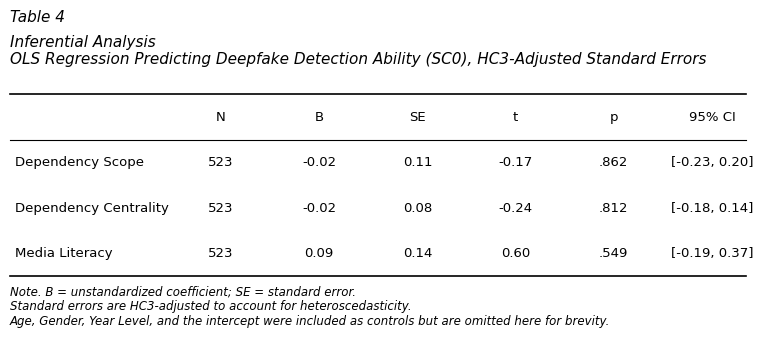

Saved: table4_model3_hc3_apa.png


In [143]:
# Table 4 - OLS Regression Results (HC3-Adjusted Standard Errors)

HC3adjust_model3 = model3.get_robustcov_results(cov_type='HC3')

# get HC3-adjusted results
params = HC3adjust_model3.params
se = HC3adjust_model3.bse
tvals = HC3adjust_model3.tvalues
pvals = HC3adjust_model3.pvalues
ci = HC3adjust_model3.conf_int()

param_names = model3.params.index  # HC3 results object doesn't retain names directly, pull from original model3

results_df = pd.DataFrame({
    'B': params,
    'SE': se,
    't': tvals,
    'p': pvals,
    'CI_lower': ci[:, 0],
    'CI_upper': ci[:, 1]
}, index=param_names)

keep_vars = ['dep_scope_score', 'dep_centrality_score', 'nmls_compscore']
name_map = {
    'dep_scope_score': 'Dependency Scope',
    'dep_centrality_score': 'Dependency Centrality',
    'nmls_compscore': 'Media Literacy',
}
results_df = results_df.loc[keep_vars]
results_df.index = [name_map[idx] for idx in results_df.index]

def fmt_p(p):
    return '< .001' if p < .001 else f'{p:.3f}'.lstrip('0')

display_df = pd.DataFrame({
    'N': [int(model3.nobs)] * len(results_df),
    'B': results_df['B'].map(lambda x: f'{x:.2f}'),
    'SE': results_df['SE'].map(lambda x: f'{x:.2f}'),
    't': results_df['t'].map(lambda x: f'{x:.2f}'),
    'p': results_df['p'].map(fmt_p),
    '95% CI': results_df.apply(lambda r: f"[{r['CI_lower']:.2f}, {r['CI_upper']:.2f}]", axis=1)
})

n_rows, n_cols = display_df.shape
fig, ax = plt.subplots(figsize=(9.5, 1.4 + 0.32 * n_rows))
ax.axis('off')

ax.text(0, 1 + 1.2/n_rows, 'Table 4', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1 + 0.5/n_rows, 'Inferential Analysis \n' \
'OLS Regression Predicting Deepfake Detection Ability (SC0), HC3-Adjusted Standard Errors', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

tbl = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.22, 0, 0.80, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)

for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02

ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
header_bottom_y = 1 - (1 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

note_y = -0.27
ax.text(0, note_y,
        'Note. B = unstandardized coefficient; SE = standard error. \n'
        'Standard errors are HC3-adjusted to account for heteroscedasticity.\n'
        'Age, Gender, Year Level, and the intercept were included as controls but are omitted here for brevity.',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')

plt.savefig('table4_model3_hc3_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: table4_model3_hc3_apa.png")

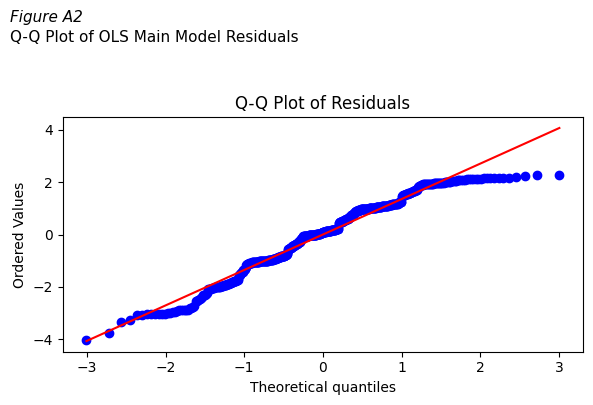

Saved: figureA2_qqplot_residuals.png


In [144]:
#Figure A2
# Test for Normal Distribution (OLS Assumption)
## Q-Q Plot (Visual)

fig, ax = plt.subplots(figsize=(6, 4))

fig.suptitle('Figure A2', fontsize=11, fontstyle='italic', x=0.02, y=1.0, ha='left')
fig.text(0.02, 0.92, 'Q-Q Plot of OLS Main Model Residuals', fontsize=11, ha='left')

stats.probplot(model3.resid, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Residuals")

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('figureA2_qqplot_residuals.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figureA2_qqplot_residuals.png")

## Numerical Tests from HC3 adjusted model
#Skewness - -0.425
#Kurtosis - 2.552

In [145]:
stat, p_value = stats.shapiro(model3.resid)
print(f"Shapiro-Wilk statistic: {stat:.4f}, p-value: {p_value:.4f}")

Shapiro-Wilk statistic: 0.9675, p-value: 0.0000


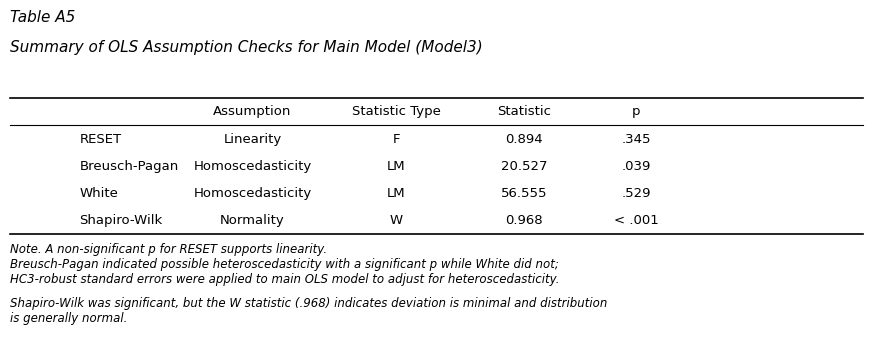

Saved: tableA5_assumptions_apa.png


In [146]:
# Table A5 - Summary of OLS Assumption Checks (APA 7th style)

assumption_data = [
    ['RESET', 'Linearity', 'F', '0.894', '.345'],
    ['Breusch-Pagan', 'Homoscedasticity', 'LM', '20.527', '.039'],
    ['White', 'Homoscedasticity', 'LM', '56.555', '.529'],
    ['Shapiro-Wilk', 'Normality', 'W', '0.968', '< .001'],
]

assump_df = pd.DataFrame(assumption_data, columns=['Test', 'Assumption', 'Statistic Type', 'Statistic', 'p'])
assump_df = assump_df.set_index('Test')

n_rows, n_cols = assump_df.shape
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')

ax.text(0, 1.28, 'Table A5', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1.16, 'Summary of OLS Assumption Checks for Main Model (Model3)', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

tbl = ax.table(
    cellText=assump_df.values,
    rowLabels=assump_df.index,
    colLabels=assump_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.20, 0.42, 0.60, 0.55],
    colWidths=[0.18, 0.18, 0.14, 0.14]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)

for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02

ax.plot([0.0, 1.0], [0.97, 0.97], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
header_bottom_y = 0.97 - (0.55 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
ax.plot([0.0, 1.0], [0.42, 0.42], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

ax.text(0, 0.28,
        'Note. A non-significant p for RESET supports linearity.\n',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 0.16,
        'Breusch-Pagan indicated possible heteroscedasticity with a significant p while White did not;\n'
        'HC3-robust standard errors were applied to main OLS model to adjust for heteroscedasticity.\n',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 0.00,
        'Shapiro-Wilk was significant, but the W statistic (.968) indicates deviation is minimal and distribution \n'
        'is generally normal.\n',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')

plt.savefig('tableA5_assumptions_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tableA5_assumptions_apa.png")

In [147]:
# EXPLORATORY ANALYSIS (Confidence in Video Classification Answer, Trust and Distrust in Media)

#Composite Scores for Confidence, Trust, and Distrust Items

confidence_items = ["CONF1_DF","CONF2_DF","CONF3_DF","CONF4_DF",
                    "CONF5_R", "CONF6_R", "CONF7_R", "CONF8_R"]                  # specify questions included
df[confidence_items] = df[confidence_items].apply(pd.to_numeric, errors="coerce")      # makes sure all values are numeric
df["confidence_compscore"] = df[confidence_items].mean(axis=1)

trust_items = ["TR1","TR2","TR3","TR4"]                  # specify questions included
df[trust_items] = df[trust_items].apply(pd.to_numeric, errors="coerce")      # makes sure all values are numeric
df["trust_compscore"] = df[trust_items].mean(axis=1)

distrust_items = ["DT1","DT2","DT3","DT4"]                  # specify questions included
df[distrust_items] = df[distrust_items].apply(pd.to_numeric, errors="coerce")      # makes sure all values are numeric
df["distrust_compscore"] = df[distrust_items].mean(axis=1)

# Verify all composite scores fall between 1 and 5 / **also shows distribution
print(df[["confidence_compscore", "trust_compscore", "distrust_compscore"]]
    .describe().round(3))  # round up 3 decimal places for readability

       confidence_compscore  trust_compscore  distrust_compscore
count               523.000          523.000             523.000
mean                  3.525            2.917               3.954
std                   0.752            0.837               0.593
min                   1.375            1.000               1.250
25%                   3.000            2.250               3.750
50%                   3.500            3.000               4.000
75%                   4.000            3.500               4.250
max                   5.000            5.000               5.000


In [148]:
# Exploratory Analysis OLS Fitting

exploratory_model = smf.ols(                                       
    "SC0 ~ confidence_compscore + trust_compscore + distrust_compscore "    # specify outcome var, indicators, and controls to fit OLS to 
    "+ C(Gender_label) + Age + C(Q('Year Level'))",                         # these are controls
    data=df                                                                 # specify which dataframe to use
).fit()
print(exploratory_model.summary())      

                            OLS Regression Results                            
Dep. Variable:                    SC0   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     4.519
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           1.52e-06
Time:                        14:50:10   Log-Likelihood:                -888.96
No. Observations:                 523   AIC:                             1802.
Df Residuals:                     511   BIC:                             1853.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

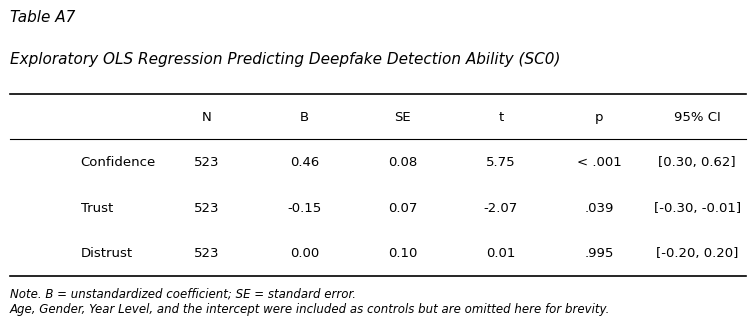

Saved: tablea7_exploratory_apa.png


In [149]:
# Table A7 - Exploratory OLS Regression Results (APA 7th style)

ci = exploratory_model.conf_int()
ci.columns = ['CI_lower', 'CI_upper']

results_df = pd.DataFrame({
    'B': exploratory_model.params,
    'SE': exploratory_model.bse,
    't': exploratory_model.tvalues,
    'p': exploratory_model.pvalues,
    'CI_lower': ci['CI_lower'],
    'CI_upper': ci['CI_upper']
})

keep_vars = ['confidence_compscore', 'trust_compscore', 'distrust_compscore']
name_map = {
    'confidence_compscore': 'Confidence',
    'trust_compscore': 'Trust',
    'distrust_compscore': 'Distrust',
}
results_df = results_df.loc[keep_vars]
results_df.index = [name_map[idx] for idx in results_df.index]

def fmt_p(p):
    return '< .001' if p < .001 else f'{p:.3f}'.lstrip('0')

display_df = pd.DataFrame({
    'N': [int(exploratory_model.nobs)] * len(results_df),
    'B': results_df['B'].map(lambda x: f'{x:.2f}'),
    'SE': results_df['SE'].map(lambda x: f'{x:.2f}'),
    't': results_df['t'].map(lambda x: f'{x:.2f}'),
    'p': results_df['p'].map(fmt_p),
    '95% CI': results_df.apply(lambda r: f"[{r['CI_lower']:.2f}, {r['CI_upper']:.2f}]", axis=1)
})

n_rows, n_cols = display_df.shape
fig, ax = plt.subplots(figsize=(9.5, 1.4 + 0.32 * n_rows))
ax.axis('off')

ax.text(0, 1 + 1.2/n_rows, 'Table A7', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')
ax.text(0, 1 + 0.5/n_rows, 'Exploratory OLS Regression Predicting Deepfake Detection Ability (SC0)', fontsize=11, fontstyle='italic', transform=ax.transAxes, ha='left')

tbl = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.20, 0, 0.80, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0)

for row_idx in range(n_rows):
    tbl[row_idx + 1, -1].get_text().set_ha('left')
    tbl[row_idx + 1, -1].PAD = 0.02

ax.plot([0.0, 1.0], [1.0, 1.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)
header_bottom_y = 1 - (1 / (n_rows + 1))
ax.plot([0.0, 1.0], [header_bottom_y, header_bottom_y], color='black', linewidth=0.8, transform=ax.transAxes, clip_on=False)
ax.plot([0.0, 1.0], [0.0, 0.0], color='black', linewidth=1.2, transform=ax.transAxes, clip_on=False)

note_y = -0.20
ax.text(0, note_y,
        'Note. B = unstandardized coefficient; SE = standard error. \n'
        'Age, Gender, Year Level, and the intercept were included as controls but are omitted here for brevity.',
        fontsize=8.5, fontstyle='italic', transform=ax.transAxes, ha='left')

plt.savefig('tablea7_exploratory_apa.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: tablea7_exploratory_apa.png")